In [22]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

In [23]:
# Set the Matplotlib style
plt.style.use('ggplot')
mpl.rcParams['lines.linewidth'] = 4
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['font.size'] = 18
mpl.rcParams['figure.titlesize'] = 25
plt.rcParams['axes.titlepad'] = 20
mpl.rcParams['font.weight'] = 'light'
mpl.rcParams['figure.facecolor'] = '#FBE3D6'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['axes.edgecolor'] = '#0E0A1F'
mpl.rcParams['grid.color'] = '#0E0A1F'
mpl.rcParams['axes.labelcolor'] = '#0E0A1F'
mpl.rcParams['lines.color'] = '#0E0A1F'
mpl.rcParams['xtick.color'] = '#0E0A1F'
mpl.rcParams['ytick.color'] = '#0E0A1F'

In [24]:
# Combine the Real Data
dfs = []

for i in range(1, 5):
    dfs.append(pd.read_csv(f'Data/Real-Data/Sample {i} reflectance h.Sample.Cycle1.Raw.csv'))    

mergeData = [dfs[0].iloc[:, 0]] + [df.iloc[:, 1] for df in dfs]

# 3. Concatenate horizontally
realData = pd.concat(mergeData, axis=1)

# 4. Assign your predefined column names
realCols = ["nm", "Sample1Ref", "Sample2Ref", "Sample3Ref", "Sample4Ref"]
realData.columns = realCols

realData = realData.iloc[::-1]

print(realData.head())

realData.to_csv("Processed/RealDataCombined-Reflectance.csv")


        nm  Sample1Ref  Sample2Ref  Sample3Ref  Sample4Ref
450  350.0   12.861306   15.866040   13.394721   12.761592
449  351.0   12.731376   15.810058   13.506158   12.690969
448  352.0   12.751664   15.809066   13.383421   12.642524
447  353.0   12.718066   15.789743   13.301711   12.680343
446  354.0   12.806545   15.676974   13.142866   12.696559


In [25]:
# Combine the Simulated Data
dfs = []

angles = [0, 5, 10, 15, 20, 45, 50, 55, 60]

for i in angles:
    dfs.append(pd.read_csv(f'Data/Simulation/MothEye_Raytracing_{i}_Perturbance_6_Layer_3_Sim2.csv'))    
    
mergeData = [dfs[0].iloc[:, 1]] + [df.iloc[:, 3] * 100 for df in dfs]

# 3. Concatenate horizontally
simulatedData = pd.concat(mergeData, axis=1)

simCols = ["nm"]

for i in angles:
    simCols.append(f"Ref-{i}")

# 4. Assign your predefined column names
simulatedData.columns = simCols

print(simulatedData.head())

simulatedData.to_csv("Processed/SimulationDataCombined-Reflectance.csv")

      nm     Ref-0     Ref-5    Ref-10    Ref-15    Ref-20    Ref-45  \
0  300.0  2.433932  2.435178  2.438995  2.448136  2.469402  3.453676   
1  301.0  2.430157  2.431028  2.434654  2.444041  2.465237  3.454387   
2  302.0  2.428308  2.428879  2.431808  2.440531  2.461431  3.448102   
3  303.0  2.423540  2.424484  2.427653  2.436708  2.457750  3.442322   
4  304.0  2.418689  2.419621  2.423386  2.432661  2.453753  3.437560   

     Ref-50    Ref-55    Ref-60  
0  4.203778  5.444916  7.496683  
1  4.198276  5.440683  7.486952  
2  4.196431  5.436440  7.481081  
3  4.187896  5.430399  7.479451  
4  4.182314  5.422208  7.475975  


In [26]:
minError = 10000000000
minTitle = "0-0"

for realCol in realCols[1:]:
    for simCol in simCols[1:]:
        
        simData = simulatedData[simCol][50:501].to_numpy()
        
        
        for i in range(len(simData)):
            difference = realData[realCol].values - simData
            dif2 = difference**2
            
            difSum = np.sum(dif2)
            
            if (difSum < minError):
                minError = difSum
                minTitle = f"{realCol}-{simCol}"
        
    
print(minError)
print(minTitle)


5080.116781503761
Sample4Ref-Ref-60


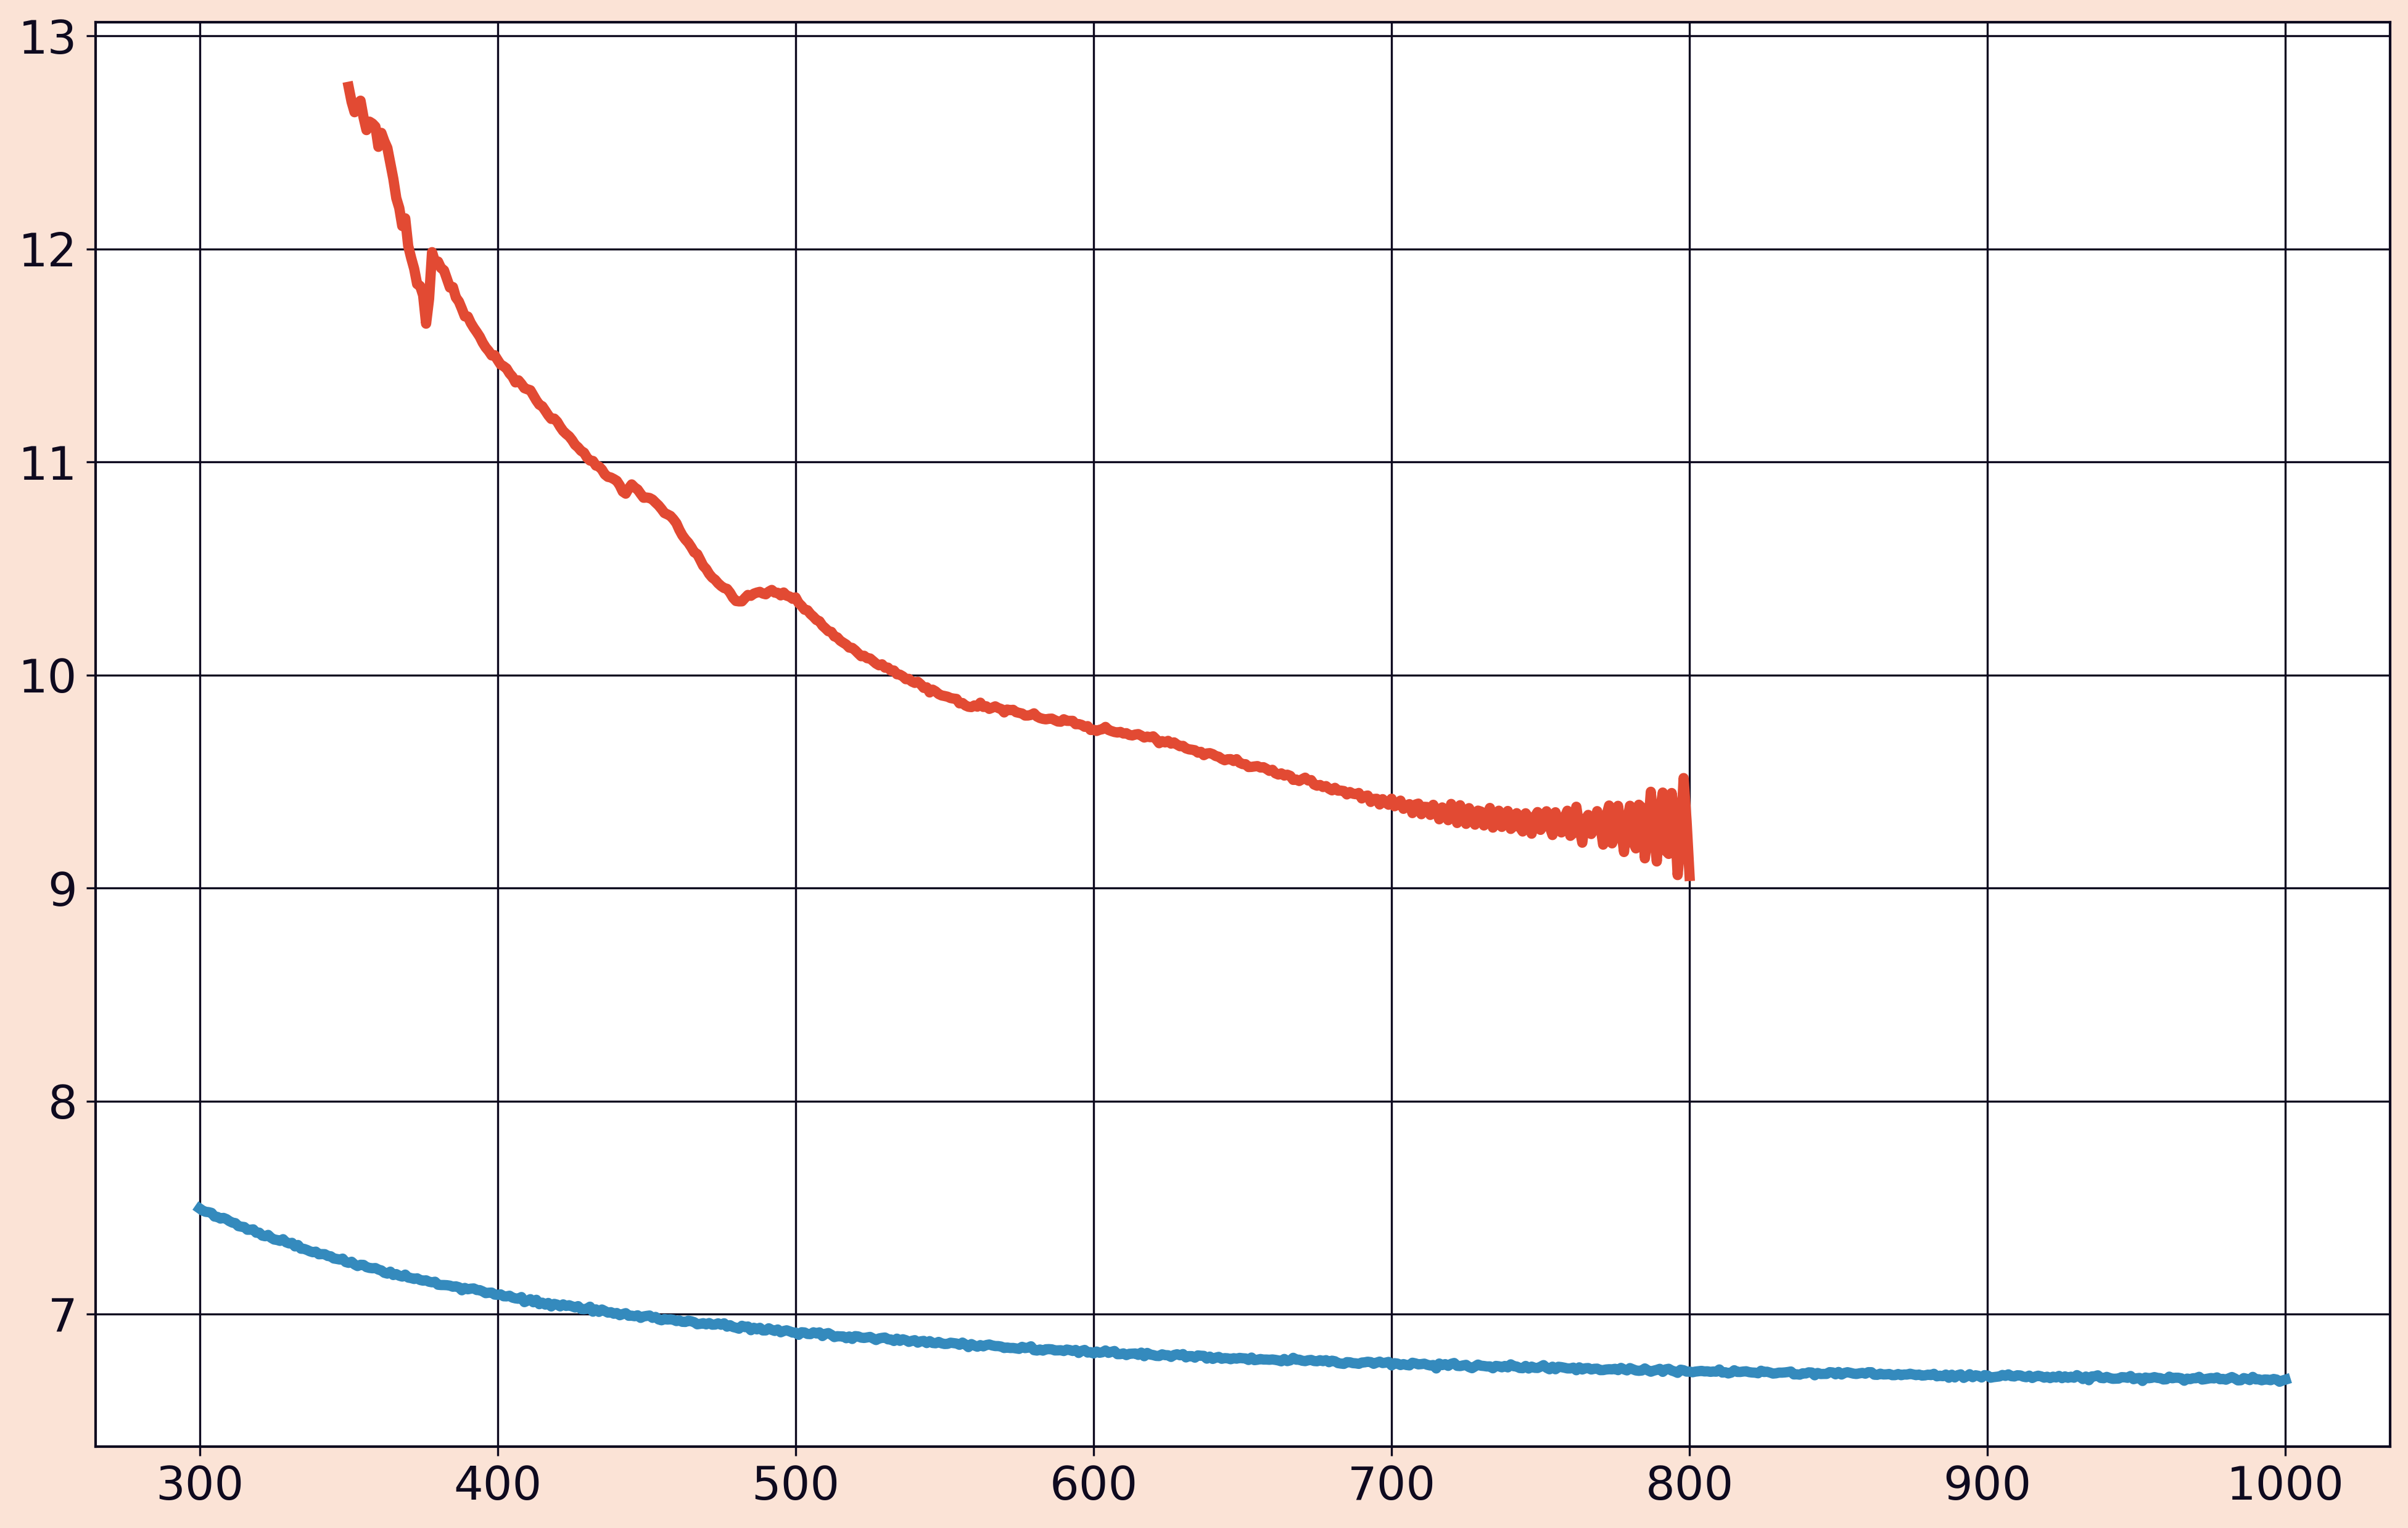

In [27]:
realWavelengths = realData["nm"].to_numpy()
simulatedWavelengths = simulatedData["nm"][50:501].to_numpy()


plt.figure(figsize=(16, 10))
plt.plot(realWavelengths, realData["Sample4Ref"])
plt.plot(simulatedData['nm'].values, simulatedData['Ref-60'].values)
plt.show()

In [28]:
bestData = pd.DataFrame(columns=["nm", "RealReflectance", "SimulatedReflectance"])

bestData["nm"] = simulatedWavelengths
bestData["RealReflectance"] = realData['Sample4Ref'].values
bestData["SimulatedReflectance"] = simulatedData["Ref-60"]

bestData.to_csv("Processed/BestData.csv", index=False)